In [1]:
!pip install kaggle

In [ ]:
# ============================================================
# Step 1: Install and setup required packages
# ============================================================

!pip install -q kaggle pyarrow fastparquet

import os
import glob
import zipfile
import pandas as pd
import numpy as np

print("Libraries loaded successfully.")


# ============================================================
# Step 2: Download dataset from Kaggle
# ============================================================

# This command downloads the dataset exactly as available on Kaggle.
# It does not change the text/data inside the dataset.

!kaggle datasets download -d dhoogla/unswnb15 -p /content/dataset


# ============================================================
# Step 3: Check downloaded files
# ============================================================

print("\nDownloaded files:")
print(os.listdir("/content/dataset"))


# ============================================================
# Step 4: Unzip downloaded dataset
# ============================================================

zip_files = glob.glob("/content/dataset/*.zip")

for zip_file in zip_files:
    print("\nUnzipping:", zip_file)

    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall("/content/dataset/extracted")

print("\nUnzip completed.")


# ============================================================
# Step 5: List all extracted files
# ============================================================

all_files = glob.glob("/content/dataset/extracted/**/*", recursive=True)

print("\nAll extracted files:")
for file in all_files:
    if os.path.isfile(file):
        print(file)


# ============================================================
# Step 6: Find CSV and Parquet files
# ============================================================

csv_files = glob.glob("/content/dataset/extracted/**/*.csv", recursive=True)
parquet_files = glob.glob("/content/dataset/extracted/**/*.parquet", recursive=True)

print("\nCSV files found:")
for file in csv_files:
    print(file)

print("\nParquet files found:")
for file in parquet_files:
    print(file)


# ============================================================
# Step 7: Read dataset correctly
# ============================================================

dataframes = []

# Read CSV files correctly
for file in csv_files:
    print("\nReading CSV file:", file)
    try:
        temp_df = pd.read_csv(file, low_memory=False)
    except UnicodeDecodeError:
        temp_df = pd.read_csv(file, low_memory=False, encoding="latin1")

    dataframes.append(temp_df)
    print("Shape:", temp_df.shape)


# Read Parquet files correctly
for file in parquet_files:
    print("\nReading Parquet file:", file)
    temp_df = pd.read_parquet(file)

    dataframes.append(temp_df)
    print("Shape:", temp_df.shape)


# ============================================================
# Step 8: Combine all readable files
# ============================================================

if len(dataframes) == 0:
    raise FileNotFoundError("No readable CSV or Parquet files found. Please check dataset files.")

df = pd.concat(dataframes, ignore_index=True)

print("\nFinal combined dataset shape:", df.shape)


# ============================================================
# Step 9: Show dataset properly
# ============================================================

print("\nFirst 5 rows of dataset:")
display(df.head())

print("\nDataset columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Libraries imported successfully.
Training dataset loaded successfully.
Training shape: (175341, 36)

Testing dataset loaded successfully.
Testing shape: (82332, 36)

First 5 rows of training dataset:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0



Target distribution in training dataset:
label
1    119341
0     56000
Name: count, dtype: int64

Target distribution in testing dataset:
label
1    45332
0    37000
Name: count, dtype: int64


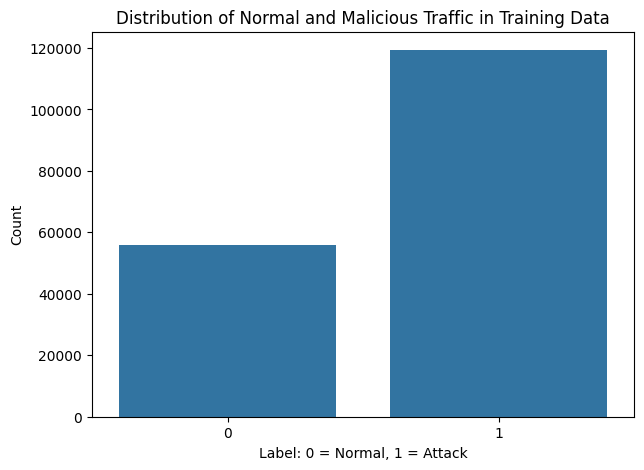


Features and target separated successfully.
X_train shape: (175341, 34)
X_test shape: (82332, 34)
y_train shape: (175341,)
y_test shape: (82332,)

Numerical columns: 31
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']

Categorical columns: 3
['proto', 'service', 'state']

Preprocessing pipeline created successfully.

Random Forest model pipeline created successfully.

Training started. Please wait...
Model training completed successfully.

Predictions completed successfully.

================ MODEL PERFORMANCE ================
Accuracy : 0.8713
Precision: 0.8272
Recall   : 0.9687
F1 Score : 0.8923

Classification Report:
              precision    recall  f1-score   support

      Norma

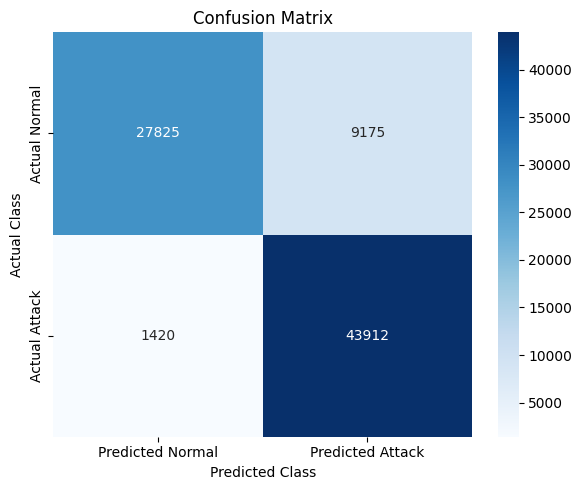


Confusion matrix saved as /content/confusion_matrix.png

Top 15 Important Features:


,Feature,Importance
7,dload,0.072807
6,sload,0.071197
20,ackdat,0.068062
4,dbytes,0.052601
3,sbytes,0.051011
10,sinpkt,0.047694
21,smean,0.047569
5,rate,0.046837
19,synack,0.046730
11,dinpkt,0.045128


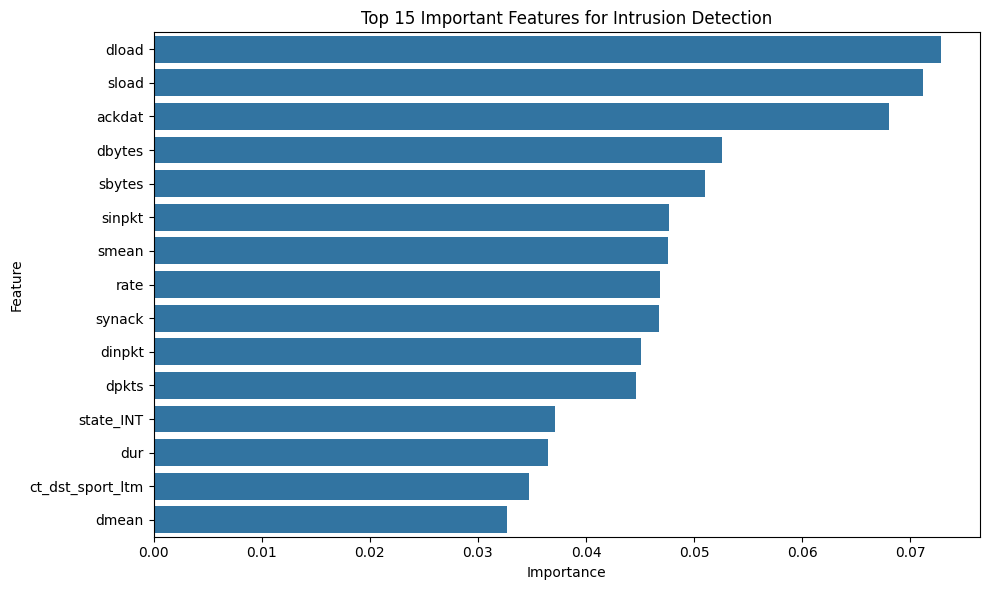


Feature importance saved as /content/feature_importance.csv
Feature importance graph saved as /content/feature_importance.png


,Metric,Result
0,Accuracy,0.871314
1,Precision,0.827170
2,Recall,0.968676
3,F1 Score,0.892348



Results summary saved as /content/model_results_summary.csv

================ SECURITY ANALYSIS ================

Security Analysis:

The Random Forest based intrusion detection model was trained using the UNSW-NB15 training dataset and tested on the separate UNSW-NB15 testing dataset.

The target variable used in this project was 'label', where 0 represents normal network traffic and 1 represents malicious or attack traffic.

The feature 'attack_cat' was removed from the input features because it directly represents the attack category and could cause data leakage. This ensures that the model learns from actual network traffic features rather than being given the answer indirectly.

The model achieved an accuracy of 0.8713, which shows the overall percentage of correct predictions.

The precision score was 0.8272. Precision shows how many predicted attacks were actually attacks. High precision means the model produces fewer false alarms.

The recall score was 0.9687. Recall is especi

In [11]:
# ============================================================
# AI-Powered Intrusion Detection System
# Model Training and Evaluation Code
# Dataset: UNSW-NB15 Parquet Files
# Target: label
# 0 = Normal Traffic
# 1 = Malicious / Attack Traffic
# ============================================================

# -------------------------------
# Step 1: Import required libraries
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")


# -------------------------------
# Step 2: Read training and testing Parquet files
# -------------------------------

train_path = "/content/dataset/extracted/UNSW_NB15_training-set.parquet"
test_path = "/content/dataset/extracted/UNSW_NB15_testing-set.parquet"

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("Training dataset loaded successfully.")
print("Training shape:", train_df.shape)

print("\nTesting dataset loaded successfully.")
print("Testing shape:", test_df.shape)


# -------------------------------
# Step 3: Display first few rows
# -------------------------------

print("\nFirst 5 rows of training dataset:")
display(train_df.head())


# -------------------------------
# Step 4: Check target distribution
# -------------------------------

print("\nTarget distribution in training dataset:")
print(train_df["label"].value_counts())

print("\nTarget distribution in testing dataset:")
print(test_df["label"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(x=train_df["label"])
plt.title("Distribution of Normal and Malicious Traffic in Training Data")
plt.xlabel("Label: 0 = Normal, 1 = Attack")
plt.ylabel("Count")
plt.show()


# -------------------------------
# Step 5: Separate features and target
# -------------------------------

# Target column
target_column = "label"

# Columns to remove from features
# label is target, attack_cat is removed to avoid data leakage
columns_to_drop = ["label", "attack_cat"]

X_train = train_df.drop(columns=columns_to_drop)
y_train = train_df[target_column]

X_test = test_df.drop(columns=columns_to_drop)
y_test = test_df[target_column]

print("\nFeatures and target separated successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# -------------------------------
# Step 6: Identify numerical and categorical columns
# -------------------------------

numerical_columns = X_train.select_dtypes(
    include=["int8", "int16", "int32", "int64", "float16", "float32", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical columns:", len(numerical_columns))
print(numerical_columns)

print("\nCategorical columns:", len(categorical_columns))
print(categorical_columns)


# -------------------------------
# Step 7: Create preprocessing pipelines
# -------------------------------

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ]
)

print("\nPreprocessing pipeline created successfully.")


# -------------------------------
# Step 8: Create Random Forest model
# -------------------------------

rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

print("\nRandom Forest model pipeline created successfully.")


# -------------------------------
# Step 9: Train the model
# -------------------------------

print("\nTraining started. Please wait...")

model_pipeline.fit(X_train, y_train)

print("Model training completed successfully.")


# -------------------------------
# Step 10: Make predictions on test data
# -------------------------------

y_pred = model_pipeline.predict(X_test)

print("\nPredictions completed successfully.")


# -------------------------------
# Step 11: Evaluate the model
# -------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n================ MODEL PERFORMANCE ================")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("===================================================")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"], zero_division=0))


# -------------------------------
# Step 12: Confusion Matrix
# -------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Attack"],
    yticklabels=["Actual Normal", "Actual Attack"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=300)
plt.show()

print("\nConfusion matrix saved as /content/confusion_matrix.png")


# -------------------------------
# Step 13: Feature Importance
# -------------------------------

try:
    trained_model = model_pipeline.named_steps["model"]
    fitted_preprocessor = model_pipeline.named_steps["preprocessor"]

    feature_names = []

    # Numerical feature names
    feature_names.extend(numerical_columns)

    # Categorical encoded feature names
    if len(categorical_columns) > 0:
        onehot_encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
        encoded_cat_features = onehot_encoder.get_feature_names_out(categorical_columns)
        feature_names.extend(encoded_cat_features)

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": trained_model.feature_importances_
    })

    feature_importance_df = feature_importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nTop 15 Important Features:")
    display(feature_importance_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=feature_importance_df.head(15),
        x="Importance",
        y="Feature"
    )
    plt.title("Top 15 Important Features for Intrusion Detection")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("/content/feature_importance.png", dpi=300)
    plt.show()

    feature_importance_df.to_csv("/content/feature_importance.csv", index=False)

    print("\nFeature importance saved as /content/feature_importance.csv")
    print("Feature importance graph saved as /content/feature_importance.png")

except Exception as e:
    print("\nFeature importance could not be generated.")
    print("Reason:", e)


# -------------------------------
# Step 14: Save results summary
# -------------------------------

results_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Result": [accuracy, precision, recall, f1]
})

display(results_summary)

results_summary.to_csv("/content/model_results_summary.csv", index=False)

print("\nResults summary saved as /content/model_results_summary.csv")


# -------------------------------
# Step 15: Security analysis for report
# -------------------------------

security_analysis = f"""
Security Analysis:

The Random Forest based intrusion detection model was trained using the UNSW-NB15 training dataset and tested on the separate UNSW-NB15 testing dataset.

The target variable used in this project was 'label', where 0 represents normal network traffic and 1 represents malicious or attack traffic.

The feature 'attack_cat' was removed from the input features because it directly represents the attack category and could cause data leakage. This ensures that the model learns from actual network traffic features rather than being given the answer indirectly.

The model achieved an accuracy of {round(accuracy, 4)}, which shows the overall percentage of correct predictions.

The precision score was {round(precision, 4)}. Precision shows how many predicted attacks were actually attacks. High precision means the model produces fewer false alarms.

The recall score was {round(recall, 4)}. Recall is especially important in intrusion detection because it shows how many actual attacks were correctly detected. A low recall would be dangerous because real malicious traffic could pass through the network undetected.

The F1-score was {round(f1, 4)}, which balances precision and recall.

In cybersecurity, false negatives are more dangerous than false positives. A false negative means malicious traffic was classified as normal, which may allow an attacker to bypass detection. A false positive means normal traffic was classified as malicious, which can create additional workload for the security team but is generally less dangerous than missing a real attack.

Overall, the model demonstrates that machine learning can support traditional Network Intrusion Detection Systems by automatically detecting suspicious network traffic.
"""

print("\n================ SECURITY ANALYSIS ================")
print(security_analysis)
print("===================================================")

with open("/content/security_analysis.txt", "w") as f:
    f.write(security_analysis)

print("\nSecurity analysis saved as /content/security_analysis.txt")


# -------------------------------
# Step 16: Final message
# -------------------------------

print("""
============================================================
MODEL TRAINING AND EVALUATION COMPLETED SUCCESSFULLY

Files saved in Colab:

1. /content/model_results_summary.csv
2. /content/confusion_matrix.png
3. /content/feature_importance.png
4. /content/feature_importance.csv
5. /content/security_analysis.txt

Use these outputs in your Word report.
============================================================
""")

In [12]:
!pip install -q streamlit pyarrow scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 37.8 MB/s eta 0:00:00


In [60]:
%%writefile app.py

import os
import time
import pandas as pd
import numpy as np
import streamlit as st
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ============================================================
# Page Configuration
# ============================================================

st.set_page_config(
    page_title="AI-Powered IDS Dashboard",
    page_icon="🛡️",
    layout="wide"
)

# ============================================================
# Custom CSS
# ============================================================

st.markdown(
    """
    <style>
    .main-title {
        font-size: 42px;
        font-weight: 800;
        color: #1f2937;
        margin-bottom: 5px;
    }

    .sub-text {
        font-size: 17px;
        color: #374151;
        margin-bottom: 25px;
    }

    .metric-card {
        background: #ffffff;
        padding: 22px;
        border-radius: 18px;
        box-shadow: 0px 4px 18px rgba(0,0,0,0.08);
        border-left: 6px solid #2563eb;
        margin-bottom: 12px;
    }

    .metric-title {
        font-size: 15px;
        color: #6b7280;
        margin-bottom: 8px;
    }

    .metric-value {
        font-size: 30px;
        font-weight: 800;
        color: #111827;
    }

    .success-box {
        background: #ecfdf5;
        color: #065f46;
        padding: 14px;
        border-radius: 12px;
        font-weight: 600;
    }

    .warning-box {
        background: #fff7ed;
        color: #9a3412;
        padding: 14px;
        border-radius: 12px;
        font-weight: 600;
    }
    </style>
    """,
    unsafe_allow_html=True
)

# ============================================================
# Helper Functions
# ============================================================

@st.cache_data
def load_data():
    train_path = "/content/dataset/extracted/UNSW_NB15_training-set.parquet"
    test_path = "/content/dataset/extracted/UNSW_NB15_testing-set.parquet"

    if not os.path.exists(train_path) or not os.path.exists(test_path):
        return None, None

    train_df = pd.read_parquet(train_path)
    test_df = pd.read_parquet(test_path)

    return train_df, test_df


def prepare_data(train_df, test_df, sample_size=None):
    """
    Prepare training and testing data.
    label is target.
    attack_cat is removed to avoid data leakage.
    """

    if sample_size is not None and sample_size < len(train_df):
        train_df = train_df.sample(
            n=sample_size,
            random_state=42
        )

    drop_cols = ["label", "attack_cat"]

    X_train = train_df.drop(
        columns=[c for c in drop_cols if c in train_df.columns],
        errors="ignore"
    )

    y_train = train_df["label"]

    X_test = test_df.drop(
        columns=[c for c in drop_cols if c in test_df.columns],
        errors="ignore"
    )

    y_test = test_df["label"]

    numerical_cols = X_train.select_dtypes(
        include=["int8", "int16", "int32", "int64", "float16", "float32", "float64"]
    ).columns.tolist()

    categorical_cols = X_train.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    return X_train, X_test, y_train, y_test, numerical_cols, categorical_cols


def train_ids_model(X_train, y_train, numerical_cols, categorical_cols, n_estimators):
    """
    Create preprocessing pipeline and train Random Forest model.
    """

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numerical_cols),
            ("cat", categorical_pipeline, categorical_cols)
        ]
    )

    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", rf_model)
        ]
    )

    pipeline.fit(X_train, y_train)

    return pipeline


def metric_card(title, value):
    st.markdown(
        f"""
        <div class="metric-card">
            <div class="metric-title">{title}</div>
            <div class="metric-value">{value}</div>
        </div>
        """,
        unsafe_allow_html=True
    )


def read_uploaded_file(uploaded_file):
    if uploaded_file is None:
        return None

    file_name = uploaded_file.name.lower()

    if file_name.endswith(".csv"):
        return pd.read_csv(uploaded_file, low_memory=False)

    if file_name.endswith(".parquet"):
        return pd.read_parquet(uploaded_file)

    return None


# ============================================================
# Load Dataset
# ============================================================

train_df, test_df = load_data()

# ============================================================
# Sidebar
# ============================================================

st.sidebar.markdown("## 🛡️ IDS Dashboard")
st.sidebar.markdown("AI-Powered Intrusion Detection Solution")
st.sidebar.markdown("---")

page = st.sidebar.radio(
    "Navigation",
    [
        "Dashboard",
        "Data Explorer",
        "Model Training",
        "Visualizations",
        "Predictions",
        "Live Detection Simulation",
        "Model History"
    ]
)

st.sidebar.markdown("---")
st.sidebar.markdown("### Dataset Source")
st.sidebar.success("UNSW-NB15 Parquet files loaded from Colab")

st.sidebar.markdown("### Target Variable")
st.sidebar.info("label\n\n0 = Normal Traffic\n\n1 = Attack Traffic")

# ============================================================
# Dataset Validation
# ============================================================

if train_df is None or test_df is None:
    st.error("Dataset files not found. Please download/extract UNSW-NB15 dataset first.")
    st.stop()

if "label" not in train_df.columns or "label" not in test_df.columns:
    st.error("The dataset must contain a label column.")
    st.stop()

# ============================================================
# Main Header
# ============================================================

st.markdown(
    '<div class="main-title">AI-Powered Intrusion Detection Dashboard</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="sub-text">A machine learning based Network Intrusion Detection System for classifying traffic as normal or malicious.</div>',
    unsafe_allow_html=True
)

# ============================================================
# Dashboard Page
# ============================================================

if page == "Dashboard":
    c1, c2, c3, c4 = st.columns(4)

    with c1:
        metric_card("Training Records", f"{train_df.shape[0]:,}")

    with c2:
        metric_card("Testing Records", f"{test_df.shape[0]:,}")

    with c3:
        metric_card("Input Features", f"{train_df.shape[1] - 2}")

    with c4:
        metric_card("Classes", "2")

    st.markdown("## Dataset Summary")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Training Dataset")
        st.write("Shape:", train_df.shape)
        st.write("Class Distribution")
        st.dataframe(
            train_df["label"]
            .value_counts()
            .rename_axis("Label")
            .reset_index(name="Count")
        )

    with col2:
        st.subheader("Testing Dataset")
        st.write("Shape:", test_df.shape)
        st.write("Class Distribution")
        st.dataframe(
            test_df["label"]
            .value_counts()
            .rename_axis("Label")
            .reset_index(name="Count")
        )

    st.markdown("## Real-World Security Scenario")

    st.write(
        """
        Organizations face continuous network intrusions, anomalous traffic, exploitation attempts,
        denial-of-service attacks, reconnaissance activities, and unauthorized access attempts.
        This dashboard demonstrates how machine learning can support a Network Intrusion Detection
        System by automatically classifying traffic as normal or malicious.
        """
    )

    st.markdown(
        """
        ### Workflow

        1. Load UNSW-NB15 network traffic dataset
        2. Preprocess numerical and categorical features
        3. Train Random Forest classifier
        4. Evaluate accuracy, precision, recall, F1-score, and confusion matrix
        5. Simulate live traffic detection using testing records
        """
    )

# ============================================================
# Data Explorer Page
# ============================================================

elif page == "Data Explorer":
    st.markdown("## Data Explorer")

    selected = st.selectbox(
        "Select Dataset",
        ["Training Dataset", "Testing Dataset"]
    )

    df = train_df if selected == "Training Dataset" else test_df

    st.write("Dataset Shape:", df.shape)

    st.markdown("### Dataset Preview")
    st.dataframe(df.head(30))

    st.markdown("### Column Data Types")
    dtype_df = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str)
    })
    st.dataframe(dtype_df)

    st.markdown("### Missing Values")
    missing_df = df.isnull().sum().reset_index()
    missing_df.columns = ["Column", "Missing Values"]
    st.dataframe(missing_df)

    st.markdown("### Descriptive Statistics")
    st.dataframe(df.describe(include="all").transpose())

# ============================================================
# Model Training Page
# ============================================================

elif page == "Model Training":
    st.markdown("## Model Training")

    st.write(
        """
        Random Forest Classifier is used because it performs well on structured network traffic data,
        handles complex feature relationships, and is suitable for binary classification of normal
        and malicious traffic.
        """
    )

    col1, col2 = st.columns(2)

    with col1:
        n_estimators = st.slider(
            "Number of Trees",
            min_value=10,
            max_value=150,
            value=50,
            step=10
        )

    with col2:
        max_sample = min(100000, train_df.shape[0])
        sample_size = st.slider(
            "Training Sample Size",
            min_value=10000,
            max_value=max_sample,
            value=min(50000, max_sample),
            step=10000
        )

    if st.button("🚀 Train Model"):
        with st.spinner("Training model. Please wait..."):
            X_train, X_test, y_train, y_test, num_cols, cat_cols = prepare_data(
                train_df,
                test_df,
                sample_size=sample_size
            )

            model = train_ids_model(
                X_train,
                y_train,
                num_cols,
                cat_cols,
                n_estimators
            )

            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)

            st.session_state["model"] = model
            st.session_state["X_test"] = X_test
            st.session_state["y_test"] = y_test
            st.session_state["y_pred"] = y_pred
            st.session_state["y_prob"] = y_prob
            st.session_state["accuracy"] = accuracy
            st.session_state["precision"] = precision
            st.session_state["recall"] = recall
            st.session_state["f1"] = f1
            st.session_state["num_cols"] = num_cols
            st.session_state["cat_cols"] = cat_cols

            new_history = pd.DataFrame({
                "Date": [time.strftime("%Y-%m-%d %H:%M:%S")],
                "Model": ["Random Forest"],
                "Trees": [n_estimators],
                "Training Sample": [sample_size],
                "Accuracy": [round(accuracy, 4)],
                "Precision": [round(precision, 4)],
                "Recall": [round(recall, 4)],
                "F1 Score": [round(f1, 4)]
            })

            if "history" not in st.session_state:
                st.session_state["history"] = new_history
            else:
                st.session_state["history"] = pd.concat(
                    [st.session_state["history"], new_history],
                    ignore_index=True
                )

        st.success("Model trained successfully.")

    if "model" in st.session_state:
        st.markdown("## Model Performance")

        a, b, c, d = st.columns(4)

        with a:
            metric_card("Accuracy", f"{st.session_state['accuracy']:.4f}")

        with b:
            metric_card("Precision", f"{st.session_state['precision']:.4f}")

        with c:
            metric_card("Recall", f"{st.session_state['recall']:.4f}")

        with d:
            metric_card("F1 Score", f"{st.session_state['f1']:.4f}")

        st.markdown("### Classification Report")

        report = classification_report(
            st.session_state["y_test"],
            st.session_state["y_pred"],
            target_names=["Normal", "Attack"],
            output_dict=True,
            zero_division=0
        )

        st.dataframe(pd.DataFrame(report).transpose())

        st.markdown(
            '<div class="success-box">Security Note: High recall is very important because missing real attacks is more dangerous than generating extra alerts.</div>',
            unsafe_allow_html=True
        )

# ============================================================
# Visualizations Page
# ============================================================

elif page == "Visualizations":
    st.markdown("## Visualization Dashboard")

    st.markdown("### Training Dataset Class Distribution")

    fig1, ax1 = plt.subplots(figsize=(6, 4))
    sns.countplot(x=train_df["label"], ax=ax1)
    ax1.set_title("Training Data Class Distribution")
    ax1.set_xlabel("0 = Normal, 1 = Attack")
    ax1.set_ylabel("Count")
    st.pyplot(fig1)

    if "model" not in st.session_state:
        st.warning("Please train the model first from the Model Training page.")
        st.stop()

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("### Confusion Matrix")

        cm = confusion_matrix(
            st.session_state["y_test"],
            st.session_state["y_pred"]
        )

        fig2, ax2 = plt.subplots(figsize=(6, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Predicted Normal", "Predicted Attack"],
            yticklabels=["Actual Normal", "Actual Attack"],
            ax=ax2
        )
        ax2.set_title("Confusion Matrix")
        ax2.set_xlabel("Predicted")
        ax2.set_ylabel("Actual")
        st.pyplot(fig2)

    with col2:
        st.markdown("### ROC Curve")

        fpr, tpr, thresholds = roc_curve(
            st.session_state["y_test"],
            st.session_state["y_prob"]
        )

        roc_auc = auc(fpr, tpr)

        fig3, ax3 = plt.subplots(figsize=(6, 4))
        ax3.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        ax3.plot([0, 1], [0, 1], linestyle="--")
        ax3.set_xlabel("False Positive Rate")
        ax3.set_ylabel("True Positive Rate")
        ax3.set_title("ROC Curve")
        ax3.legend()
        st.pyplot(fig3)

    st.markdown("### Feature Importance")

    model = st.session_state["model"]
    rf = model.named_steps["model"]
    preprocessor = model.named_steps["preprocessor"]

    feature_names = []
    feature_names.extend(st.session_state["num_cols"])

    if len(st.session_state["cat_cols"]) > 0:
        encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]
        encoded_names = encoder.get_feature_names_out(st.session_state["cat_cols"])
        feature_names.extend(encoded_names)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": rf.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    st.dataframe(importance_df.head(20))

    fig4, ax4 = plt.subplots(figsize=(9, 6))
    sns.barplot(
        data=importance_df.head(15),
        x="Importance",
        y="Feature",
        ax=ax4
    )
    ax4.set_title("Top 15 Important Features")
    st.pyplot(fig4)

# ============================================================
# Predictions Page
# ============================================================

elif page == "Predictions":
    st.markdown("## Batch Predictions")

    if "model" not in st.session_state:
        st.warning("Please train the model first from the Model Training page.")
        st.stop()

    uploaded_file = st.file_uploader(
        "Upload CSV or Parquet file for prediction",
        type=["csv", "parquet"]
    )

    if uploaded_file is not None:
        pred_df = read_uploaded_file(uploaded_file)

        if pred_df is None:
            st.error("Unsupported file type.")
            st.stop()

        st.markdown("### Uploaded Data Preview")
        st.dataframe(pred_df.head())

        input_df = pred_df.drop(
            columns=[c for c in ["label", "attack_cat"] if c in pred_df.columns],
            errors="ignore"
        )

        preds = st.session_state["model"].predict(input_df)

        result_df = pred_df.copy()
        result_df["Predicted_Label"] = preds
        result_df["Prediction"] = result_df["Predicted_Label"].map({
            0: "Normal",
            1: "Attack"
        })

        st.markdown("### Prediction Results")
        st.dataframe(result_df.head(50))

        csv = result_df.to_csv(index=False).encode("utf-8")

        st.download_button(
            "Download Prediction Results",
            csv,
            "prediction_results.csv",
            "text/csv"
        )

# ============================================================
# Live Detection Simulation Page
# ============================================================

elif page == "Live Detection Simulation":
    st.markdown("## Live Detection Simulation")

    st.write(
        """
        This section simulates real-time intrusion detection by automatically feeding
        network traffic records from the testing dataset into the trained model.
        Each record is classified as Normal or Attack.
        """
    )

    if "model" not in st.session_state:
        st.warning("Please train the model first from the Model Training page.")
        st.stop()

    simulation_rows = st.slider(
        "Number of traffic records to simulate",
        min_value=5,
        max_value=100,
        value=20,
        step=5
    )

    delay = st.slider(
        "Delay between records in seconds",
        min_value=0.1,
        max_value=2.0,
        value=0.5,
        step=0.1
    )

    if st.button("▶ Start Live Simulation"):
        traffic_sample = test_df.sample(
            n=simulation_rows,
            random_state=42
        ).reset_index(drop=True)

        input_data = traffic_sample.drop(
            columns=[c for c in ["label", "attack_cat"] if c in traffic_sample.columns],
            errors="ignore"
        )

        result_box = st.empty()
        table_box = st.empty()

        live_results = []

        for i in range(simulation_rows):
            single_record = input_data.iloc[[i]]
            prediction = st.session_state["model"].predict(single_record)[0]

            actual_label = traffic_sample.loc[i, "label"]

            if prediction == 1:
                prediction_text = "Attack / Malicious"
                alert_status = "High Risk"
            else:
                prediction_text = "Normal"
                alert_status = "Safe"

            live_results.append({
                "Traffic No.": i + 1,
                "Predicted Label": int(prediction),
                "Prediction": prediction_text,
                "Actual Label": int(actual_label),
                "Alert Status": alert_status
            })

            if prediction == 1:
                result_box.error(
                    f"Traffic Record {i + 1}: Attack / Malicious Traffic Detected"
                )
            else:
                result_box.success(
                    f"Traffic Record {i + 1}: Normal Traffic Detected"
                )

            table_box.dataframe(pd.DataFrame(live_results))

            time.sleep(delay)

        st.success("Live detection simulation completed.")

# ============================================================
# Model History Page
# ============================================================

elif page == "Model History":
    st.markdown("## Model Performance History")

    if "history" not in st.session_state:
        st.warning("No model has been trained yet.")
    else:
        st.dataframe(st.session_state["history"])

    st.markdown("### Project Interpretation")

    st.write(
        """
        This dashboard represents the complete ML-based IDS workflow: dataset exploration,
        preprocessing, model training, evaluation, visualization, batch prediction, and simulated
        live threat detection. It can be included in the GitHub repository as a demonstration
        interface for the intrusion detection solution.
        """
    )

Overwriting app.py


In [35]:
from pathlib import Path

app_path = Path("/content/app.py")
text = app_path.read_text()

old_code = '''    if sample_size is not None and sample_size < len(train_df):
        train_df = train_df.sample(
            n=sample_size,
            random_state=42,
            stratify=train_df["label"]
        )
'''

new_code = '''    if sample_size is not None and sample_size < len(train_df):
        # pandas DataFrame.sample() does not support stratify.
        # Simple random sampling is used for faster dashboard demonstration.
        train_df = train_df.sample(
            n=sample_size,
            random_state=42
        )
'''

if old_code in text:
    text = text.replace(old_code, new_code)
    app_path.write_text(text)
    print("app.py fixed successfully.")
else:
    print("Exact old code block not found. I will try an alternative fix.")


app.py fixed successfully.


In [52]:
!streamlit run app.py &>/content/streamlit_logs.txt &

In [53]:
!pkill -f streamlit
!pkill -f localtunnel
!pkill -f cloudflared

In [54]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.headless true > /content/streamlit_logs.txt 2>&1 &

In [61]:
!pkill -f streamlit
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.headless true > /content/streamlit_logs.txt 2>&1 &

In [ ]:
!pkill -f cloudflared
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8501

2026-05-16T20:50:48Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-16T20:50:48Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-16T20:50:51Z INF +--------------------------------------------------------------------------------------------+
2026-05-16T20:50:51Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-16T20:50:51Z INF |  https://lately-sense-click-evening.trycloudflare.com 